# Surface Code Decoding Pipeline

This notebook demonstrates the modular QEC pipeline:
- Surface code circuit generation with configurable noise
- Pluggable decoder interface
- Logical error rate estimation with confidence intervals
- Threshold plot comparison across decoders

In [1]:
import stim
import pymatching
print(stim.__version__)
print(pymatching.__version__)

1.15.0
2.3.1


In [2]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from qec_surface.circuits import build_surface_code, NoiseModel
from qec_surface.decoders import MWPMDecoder, BeliefPropagationDecoder, BPOSDDecoder
from qec_surface.benchmark import estimate_logical_error_rate, sweep_noise_levels, compare_decoders

noise = NoiseModel.uniform(0.01)
sc = build_surface_code(distance=3, rounds=3, noise=noise)
print(sc)

SurfaceCodeCircuit(type=surface_code:rotated_memory_x, d=3, rounds=3, noise=[depol=0.0100, meas=0.0100, reset=0.0100])


## 1. Inspect a single circuit

Before running experiments, it's useful to inspect what stim actually generates.
The rotated surface code has d² data qubits and d²-1 ancilla qubits.

SurfaceCodeCircuit(type=surface_code:rotated_memory_x, d=3, rounds=3, noise=[depol=0.0100, meas=0.0100, reset=0.0100])
Data qubits:    9
Ancilla qubits: 8
DEM errors:     76


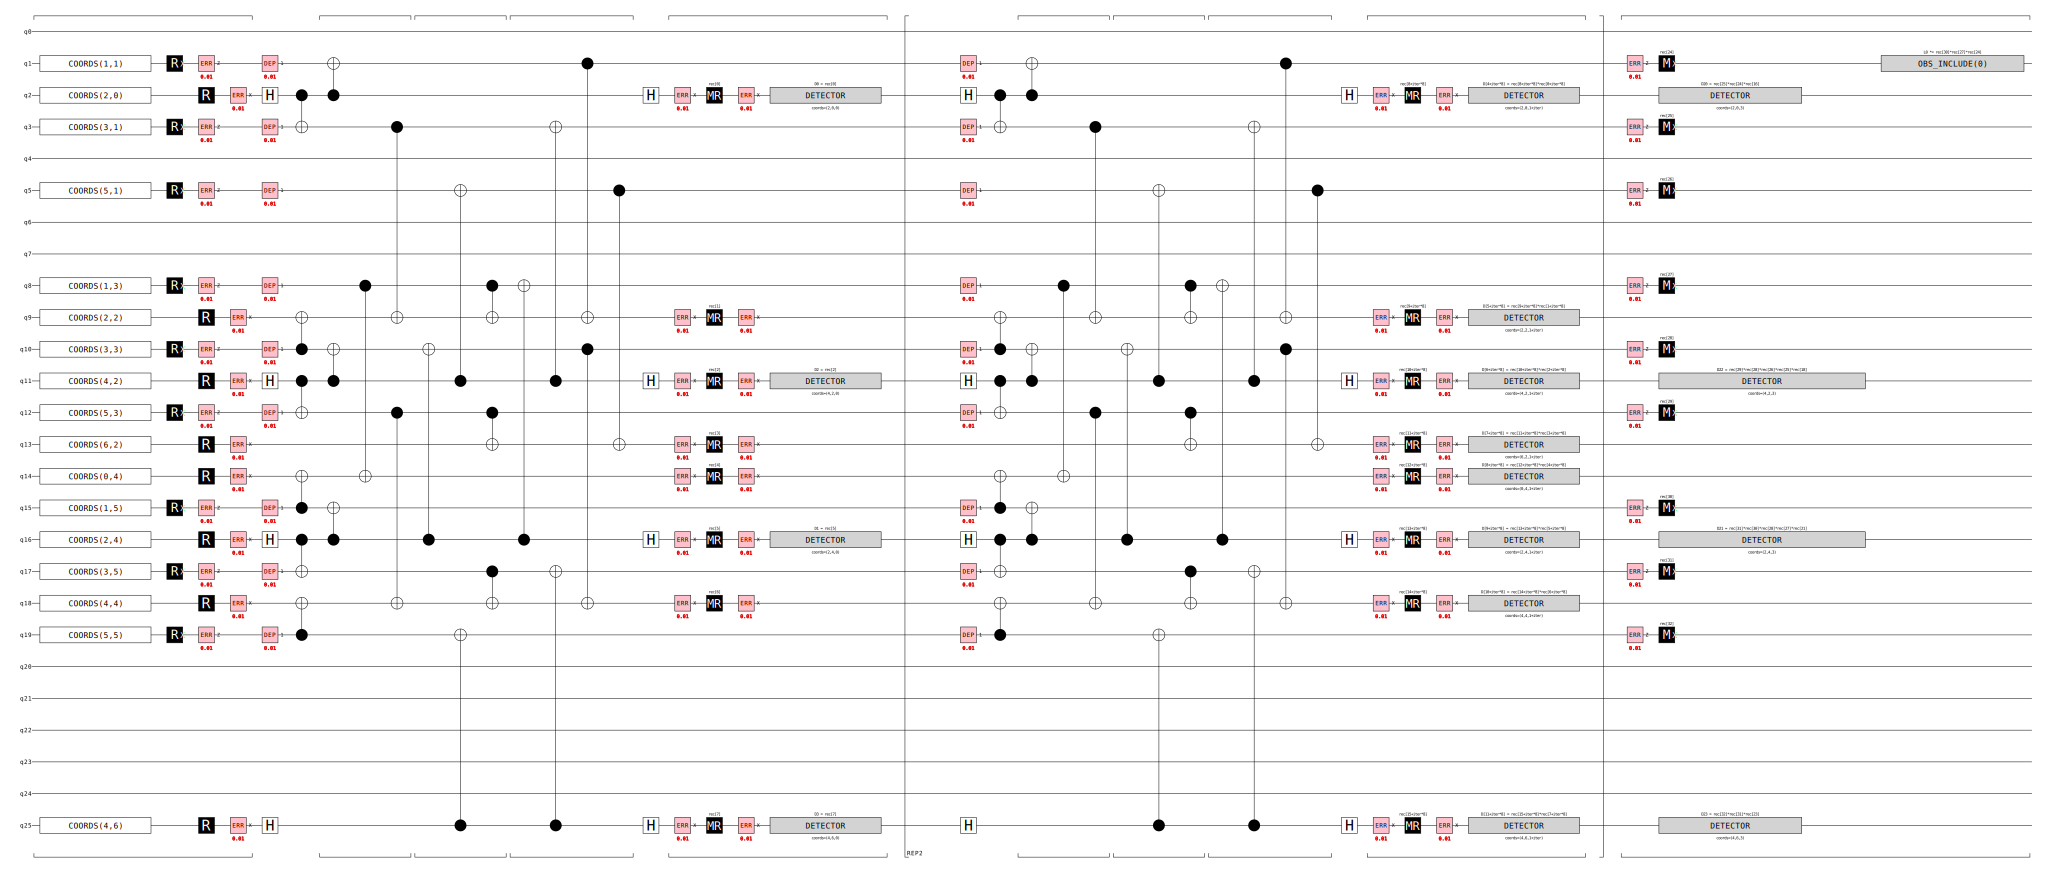

In [3]:
sc = build_surface_code(
    distance=3,
    rounds=3,
    noise=NoiseModel.uniform(0.01)
)
print(sc)
print(f"Data qubits:    {sc.n_data_qubits}")
print(f"Ancilla qubits: {sc.n_ancilla_qubits}")
print(f"DEM errors:     {sc.detector_error_model().num_errors}")

# Visualize the circuit timeline (renders in Jupyter)
sc.circuit.diagram('timeline-svg')

## 2. MWPM threshold sweep

The threshold is the noise level where curves for different distances cross.
For depolarizing circuit-level noise on the rotated surface code,
theory and simulation give p_th ≈ 1% (Fowler et al. 2012).

In [4]:
distances = [3, 5, 7]
noise_levels = [0.001, 0.003, 0.007, 0.01, 0.02, 0.05]
N_SAMPLES = 50_000

df_mwpm = sweep_noise_levels(
    distances=distances,
    noise_levels=noise_levels,
    decoder_cls=MWPMDecoder,
    n_samples=N_SAMPLES,
)

  d=3, p=0.0010 → LER=0.0002 ± 0.0001 (8/50000)
  d=3, p=0.0030 → LER=0.0013 ± 0.0003 (63/50000)
  d=3, p=0.0070 → LER=0.0071 ± 0.0007 (354/50000)
  d=3, p=0.0100 → LER=0.0148 ± 0.0011 (738/50000)
  d=3, p=0.0200 → LER=0.0549 ± 0.0020 (2743/50000)
  d=3, p=0.0500 → LER=0.2189 ± 0.0036 (10944/50000)
  d=5, p=0.0010 → LER=0.0001 ± 0.0001 (4/50000)
  d=5, p=0.0030 → LER=0.0001 ± 0.0001 (4/50000)
  d=5, p=0.0070 → LER=0.0017 ± 0.0004 (84/50000)
  d=5, p=0.0100 → LER=0.0048 ± 0.0006 (239/50000)
  d=5, p=0.0200 → LER=0.0372 ± 0.0017 (1861/50000)
  d=5, p=0.0500 → LER=0.2868 ± 0.0040 (14338/50000)
  d=7, p=0.0010 → LER=0.0000 ± 0.0000 (0/50000)
  d=7, p=0.0030 → LER=0.0000 ± 0.0001 (2/50000)
  d=7, p=0.0070 → LER=0.0005 ± 0.0002 (26/50000)
  d=7, p=0.0100 → LER=0.0014 ± 0.0003 (72/50000)
  d=7, p=0.0200 → LER=0.0238 ± 0.0013 (1188/50000)
  d=7, p=0.0500 → LER=0.3492 ± 0.0042 (17459/50000)


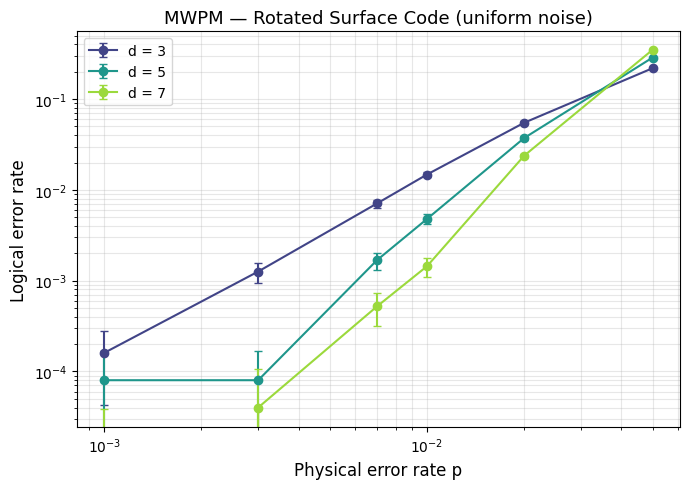

In [5]:
def plot_threshold(df, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = cm.viridis(np.linspace(0.2, 0.85, len(df['distance'].unique())))

    for color, d in zip(colors, sorted(df['distance'].unique())):
        sub = df[df['distance'] == d].sort_values('noise_level')
        ax.errorbar(
            sub['noise_level'],
            sub['logical_error_rate'],
            yerr=sub['error_bar'],
            marker='o', capsize=3, label=f'd = {d}', color=color
        )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Physical error rate p', fontsize=12)
    ax.set_ylabel('Logical error rate', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_threshold(df_mwpm, 'MWPM — Rotated Surface Code (uniform noise)')

## 3. Decoder comparison

Compare MWPM, Union-Find, and BP on the same noise sweep.

Expected behavior:
- **MWPM**: highest threshold (~1%)
- **Union-Find**: slightly lower threshold, but faster per shot
- **BP**: noticeably lower threshold due to short cycles in the surface code Tanner graph
- **BP+OSD**: close to MWPM, but much slower

In [6]:
# Use a single distance to make the comparison (relatively) fast
COMPARISON_DISTANCE = 5

df_comparison = compare_decoders(
    distances=[COMPARISON_DISTANCE],
    noise_levels=noise_levels,
    decoder_classes=[MWPMDecoder, BeliefPropagationDecoder, BPOSDDecoder],
    n_samples=N_SAMPLES,
)


── Decoder: MWPMDecoder ──
  d=5, p=0.0010 → LER=0.0000 ± 0.0000 (0/50000)
  d=5, p=0.0030 → LER=0.0001 ± 0.0001 (5/50000)
  d=5, p=0.0070 → LER=0.0017 ± 0.0004 (84/50000)
  d=5, p=0.0100 → LER=0.0051 ± 0.0006 (253/50000)
  d=5, p=0.0200 → LER=0.0361 ± 0.0016 (1807/50000)
  d=5, p=0.0500 → LER=0.2863 ± 0.0040 (14314/50000)

── Decoder: BeliefPropagationDecoder ──
  d=5, p=0.0010 → LER=0.0001 ± 0.0001 (7/50000)
  d=5, p=0.0030 → LER=0.0011 ± 0.0003 (57/50000)
  d=5, p=0.0070 → LER=0.0065 ± 0.0007 (325/50000)
  d=5, p=0.0100 → LER=0.0159 ± 0.0011 (793/50000)
  d=5, p=0.0200 → LER=0.0856 ± 0.0025 (4281/50000)
  d=5, p=0.0500 → LER=0.3977 ± 0.0043 (19887/50000)

── Decoder: BPOSDDecoder ──
  d=5, p=0.0010 → LER=0.0000 ± 0.0000 (0/50000)
  d=5, p=0.0030 → LER=0.0000 ± 0.0001 (2/50000)
  d=5, p=0.0070 → LER=0.0011 ± 0.0003 (53/50000)
  d=5, p=0.0100 → LER=0.0034 ± 0.0005 (172/50000)
  d=5, p=0.0200 → LER=0.0271 ± 0.0014 (1353/50000)
  d=5, p=0.0500 → LER=0.2681 ± 0.0039 (13403/50000)


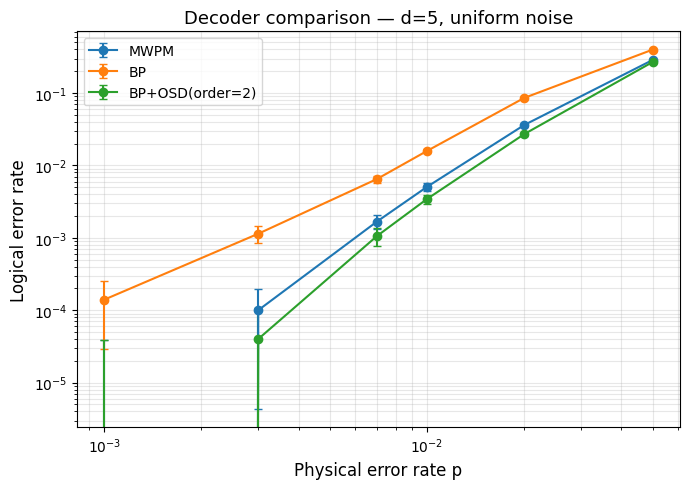

In [7]:
def plot_decoder_comparison(df, distance, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    sub = df[df['distance'] == distance]

    for decoder_name in sub['decoder_name'].unique():
        d_sub = sub[sub['decoder_name'] == decoder_name].sort_values('noise_level')
        ax.errorbar(
            d_sub['noise_level'],
            d_sub['logical_error_rate'],
            yerr=d_sub['error_bar'],
            marker='o', capsize=3, label=decoder_name
        )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Physical error rate p', fontsize=12)
    ax.set_ylabel('Logical error rate', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_decoder_comparison(
    df_comparison,
    distance=COMPARISON_DISTANCE,
    title=f'Decoder comparison — d={COMPARISON_DISTANCE}, uniform noise'
)

## 4. Noise model comparison (same decoder)

How does the threshold change when measurement errors dominate vs gate errors?

This is physically relevant: superconducting qubits often have measurement
fidelity as the bottleneck, while trapped ions typically have worse 2-qubit gates.

  d=3, p=0.0010 → LER=0.0002 ± 0.0001 (19/100000)
  d=3, p=0.0030 → LER=0.0015 ± 0.0002 (151/100000)
  d=3, p=0.0070 → LER=0.0076 ± 0.0005 (764/100000)
  d=3, p=0.0100 → LER=0.0145 ± 0.0007 (1453/100000)
  d=3, p=0.0200 → LER=0.0520 ± 0.0014 (5198/100000)
  d=3, p=0.0500 → LER=0.2201 ± 0.0026 (22011/100000)
  d=5, p=0.0010 → LER=0.0000 ± 0.0000 (1/100000)
  d=5, p=0.0030 → LER=0.0001 ± 0.0001 (12/100000)
  d=5, p=0.0070 → LER=0.0018 ± 0.0003 (176/100000)
  d=5, p=0.0100 → LER=0.0048 ± 0.0004 (478/100000)
  d=5, p=0.0200 → LER=0.0376 ± 0.0012 (3757/100000)
  d=5, p=0.0500 → LER=0.2897 ± 0.0028 (28969/100000)
  d=7, p=0.0010 → LER=0.0000 ± 0.0000 (0/100000)
  d=7, p=0.0030 → LER=0.0000 ± 0.0000 (1/100000)
  d=7, p=0.0070 → LER=0.0003 ± 0.0001 (35/100000)
  d=7, p=0.0100 → LER=0.0017 ± 0.0003 (167/100000)
  d=7, p=0.0200 → LER=0.0240 ± 0.0009 (2399/100000)
  d=7, p=0.0500 → LER=0.3402 ± 0.0029 (34023/100000)
  d=3, p=0.0010 → LER=0.0000 ± 0.0000 (3/100000)
  d=3, p=0.0030 → LER=0.0002 ± 0

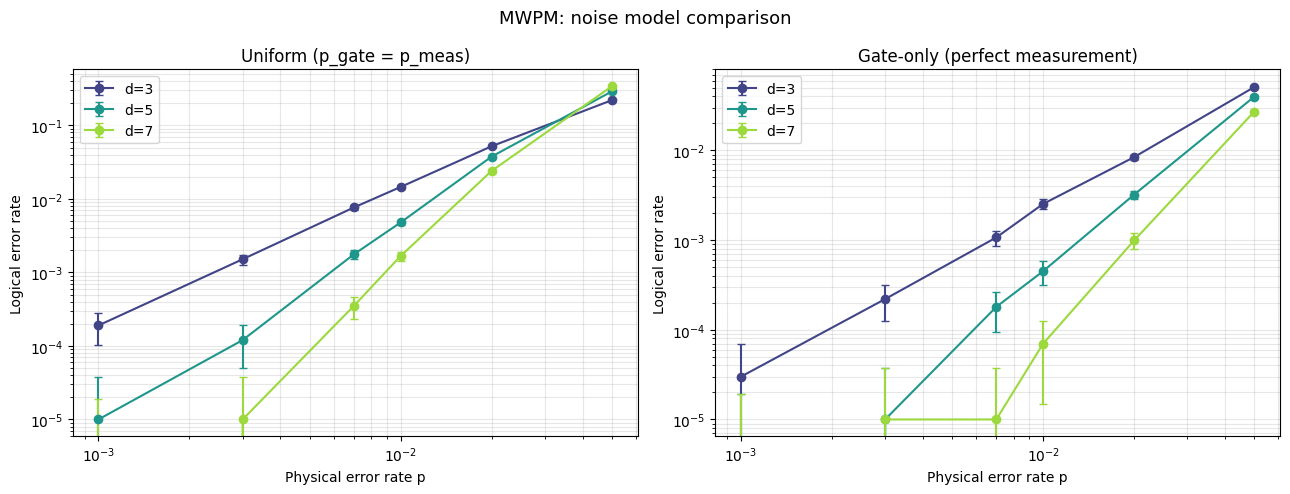

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
noise_models = {
    'Uniform (p_gate = p_meas)': NoiseModel.uniform,
    'Gate-only (perfect measurement)': NoiseModel.gate_only,
}

for ax, (label, factory) in zip(axes, noise_models.items()):
    colors = cm.viridis(np.linspace(0.2, 0.85, len(distances)))
    df = sweep_noise_levels(
        distances=distances,
        noise_levels=noise_levels,
        decoder_cls=MWPMDecoder,
        n_samples=100000,
        noise_factory=factory,
    )
    for color, d in zip(colors, sorted(df['distance'].unique())):
        sub = df[df['distance'] == d].sort_values('noise_level')
        ax.errorbar(
            sub['noise_level'], sub['logical_error_rate'],
            yerr=sub['error_bar'], marker='o', capsize=3,
            label=f'd={d}', color=color
        )
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Physical error rate p')
    ax.set_ylabel('Logical error rate')
    ax.set_title(label)
    ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.suptitle('MWPM: noise model comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

df_mwpm = compare_decoders(
    distances=[3, 5, 7],
    noise_levels=[0.001, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05],
    decoder_classes=[MWPMDecoder],
    n_samples=50_000,
)

df_bp = compare_decoders(
    distances=[3, 5, 7],
    noise_levels=[0.001, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05],
    decoder_classes=[BeliefPropagationDecoder, BPOSDDecoder],
    n_samples=10_000,
)

df_all = pd.concat([df_mwpm, df_bp], ignore_index=True)
print(f"Total data points: {len(df_all)}")


── Decoder: MWPMDecoder ──
  d=3, p=0.0010 → LER=0.0001 ± 0.0001 (7/50000)
  d=3, p=0.0030 → LER=0.0015 ± 0.0003 (74/50000)
  d=3, p=0.0050 → LER=0.0046 ± 0.0006 (231/50000)
  d=3, p=0.0070 → LER=0.0078 ± 0.0008 (390/50000)
  d=3, p=0.0100 → LER=0.0153 ± 0.0011 (767/50000)
  d=3, p=0.0150 → LER=0.0322 ± 0.0015 (1609/50000)
  d=3, p=0.0200 → LER=0.0534 ± 0.0020 (2669/50000)
  d=3, p=0.0300 → LER=0.1042 ± 0.0027 (5211/50000)
  d=3, p=0.0500 → LER=0.2221 ± 0.0036 (11103/50000)
  d=5, p=0.0010 → LER=0.0000 ± 0.0000 (0/50000)
  d=5, p=0.0030 → LER=0.0001 ± 0.0001 (4/50000)
  d=5, p=0.0050 → LER=0.0006 ± 0.0002 (30/50000)
  d=5, p=0.0070 → LER=0.0017 ± 0.0004 (83/50000)
  d=5, p=0.0100 → LER=0.0047 ± 0.0006 (237/50000)
  d=5, p=0.0150 → LER=0.0165 ± 0.0011 (826/50000)
  d=5, p=0.0200 → LER=0.0386 ± 0.0017 (1929/50000)
  d=5, p=0.0300 → LER=0.1060 ± 0.0027 (5299/50000)
  d=5, p=0.0500 → LER=0.2868 ± 0.0040 (14342/50000)
  d=7, p=0.0010 → LER=0.0000 ± 0.0000 (0/50000)
  d=7, p=0.0030 → LER=0.

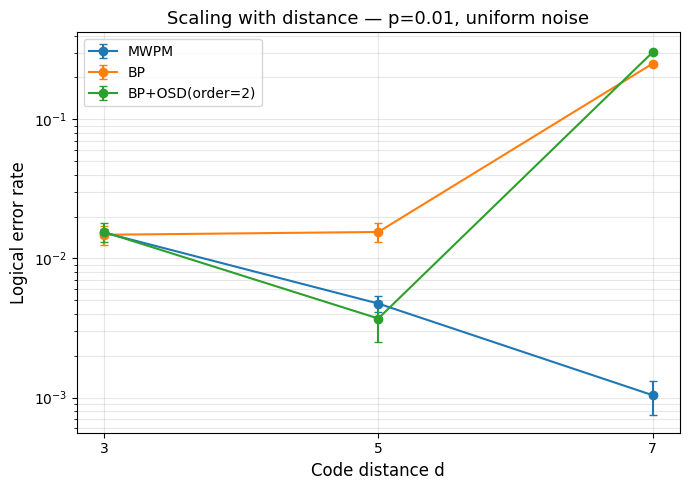

In [10]:
def plot_scaling_with_distance(df, noise_level, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    for decoder_name in df['decoder_name'].unique():
        sub = df[
            (df['decoder_name'] == decoder_name) &
            (df['noise_level'] == noise_level)
        ].sort_values('distance')
        ax.errorbar(
            sub['distance'],
            sub['logical_error_rate'],
            yerr=sub['error_bar'],
            marker='o', capsize=3, label=decoder_name
        )

    ax.set_yscale('log')
    ax.set_xlabel('Code distance d', fontsize=12)
    ax.set_ylabel('Logical error rate', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xticks([3, 5, 7])
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scaling_with_distance(
    df_all,
    noise_level=0.01,
    title='Scaling with distance — p=0.01, uniform noise'
)